In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ========= Config =========
csv_path  = "/Users/shiyalin/Desktop/patient_features_final_with_past.csv"  
unit_col  = "encounter_medical_service"
start_col = "encounter_start_dt"
end_col   = "encounter_end_dt"

# Departments to keep
keep_units = ["Nursing - medical / surgical", "Emergency medicine"]

# Fixed 100-day window
window_start = pd.Timestamp("2022-11-15")
window_days  = 100
window_end   = window_start + pd.Timedelta(days=window_days - 1)  

# Output file (single CSV)
out_csv = "./encounter_timeseries_pivot_selected_100d.csv"  

# ========= Helpers =========
def to_utc_naive(series):
    """
    Parse to datetime with UTC timezone, then drop timezone to get UTC-naive.
    This prevents tz-aware vs tz-naive comparison errors.
    """
    dt = pd.to_datetime(series, errors="coerce", utc=True)  # tz-aware (UTC)
    return dt.dt.tz_localize(None)                          # drop tz → naive

# ========= 1) Load & basic filtering =========
df = pd.read_csv(csv_path, low_memory=False)

missing = [c for c in [unit_col, start_col, end_col] if c not in df.columns]
assert not missing, f"Missing required columns: {missing}"

# Keep only the two departments of interest
df = df[df[unit_col].isin(keep_units)].copy()

# ========= 2) Parse datetimes (UTC-naive) & normalize to dates =========
df["_start_dt"] = to_utc_naive(df[start_col])
df["_end_dt"]   = to_utc_naive(df[end_col])
df = df.dropna(subset=["_start_dt", "_end_dt"]).copy()

# If end < start (dirty records), swap them
swap = df["_end_dt"] < df["_start_dt"]
if swap.any():
    tmp = df.loc[swap, "_start_dt"].copy()
    df.loc[swap, "_start_dt"] = df.loc[swap, "_end_dt"]
    df.loc[swap, "_end_dt"]   = tmp

# Normalize to pure dates (strip time-of-day)
df["_start_date"] = df["_start_dt"].dt.normalize()
df["_end_date"]   = df["_end_dt"].dt.normalize()

# ========= 3) Clip encounters to the fixed window =========
# Clip to [window_start, window_end]; drop encounters with no overlap after clipping.
df["_start_clip"] = df["_start_date"].where(df["_start_date"] >= window_start, window_start)
df["_end_clip"]   = df["_end_date"]  .where(df["_end_date"]   <= window_end,   window_end)
df = df[df["_start_clip"] <= df["_end_clip"]].copy()

In [2]:
# ========= 4) Build event table (per department) =========
# +1 at start_clip (enter), -1 at end_clip + 1 day (leave takes effect next day)
starts = (
    df[[unit_col, "_start_clip"]]
    .assign(delta=1)
    .rename(columns={"_start_clip": "date"})
)
ends = (
    df[[unit_col, "_end_clip"]]
    .assign(date=lambda x: x["_end_clip"] + pd.Timedelta(days=1), delta=-1)
    [[unit_col, "date", "delta"]]
)
events = pd.concat([starts, ends], ignore_index=True)

# Keep only event dates within [window_start, window_end+1]
events = events[(events["date"] >= window_start) & (events["date"] <= window_end + pd.Timedelta(days=1))].copy()

# Aggregate net delta per (department, date)
events_agg = events.groupby([unit_col, "date"], as_index=False)["delta"].sum()

# ========= 5) Construct daily counts per department within the window =========
def build_unit_timeseries(group):
    """
    For a single department:
    - Reindex event deltas over [window_start, window_end+1]
    - Cumulative sum to get daily counts
    - Then trim back to [window_start, window_end]
    """
    g = group.sort_values("date").copy()
    full_idx = pd.date_range(window_start, window_end + pd.Timedelta(days=1), freq="D")
    g_full = (
        g.set_index("date")
         .reindex(full_idx)
         .rename_axis("date")
         .assign(**{unit_col: g[unit_col].iloc[0]})
         .fillna({"delta": 0})
         .reset_index()
    )
    g_full["count"] = g_full["delta"].cumsum()
    g_full = g_full[(g_full["date"] >= window_start) & (g_full["date"] <= window_end)].copy()
    return g_full[[unit_col, "date", "count"]]

timeseries = (
    events_agg.groupby(unit_col, group_keys=False)
    .apply(build_unit_timeseries)
    .reset_index(drop=True)
)

/var/folders/s2/ly676psd1glf19n7hggl68400000gn/T/ipykernel_11900/2948235910.py:44: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  events_agg.groupby(unit_col, group_keys=False)


In [3]:
# ========= 6) Pivot to one 100-day table (date x department) =========
pivot = (
    timeseries
    .pivot(index="date", columns=unit_col, values="count")
    .sort_index()
)

# Make sure columns appear in the desired order
pivot = pivot.reindex(columns=keep_units)
pivot.to_csv(out_csv)
print("Saved 100-day pivot CSV to:", out_csv)
print("\nPivot head (100-day window):")
print(pivot.head(10))

Saved 100-day pivot CSV to: ./encounter_timeseries_pivot_selected_100d.csv

Pivot head (100-day window):
encounter_medical_service  Nursing - medical / surgical  Emergency medicine
date                                                                       
2022-11-15                                          661                  31
2022-11-16                                          680                  31
2022-11-17                                          713                  35
2022-11-18                                          762                  30
2022-11-19                                          789                  52
2022-11-20                                          792                  37
2022-11-21                                          821                  42
2022-11-22                                          843                  40
2022-11-23                                          869                  34
2022-11-24                                          880    

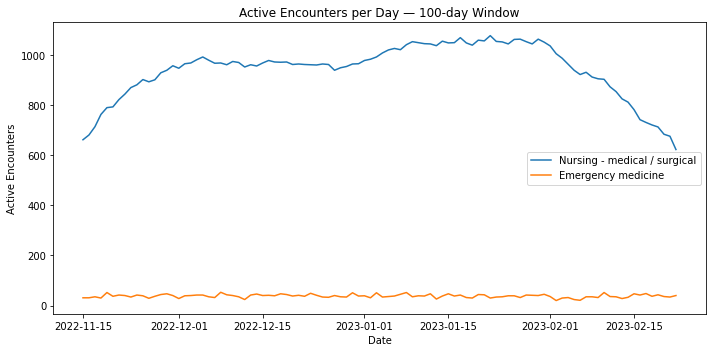

In [4]:
# Show a quick comparison plot (not saved)
plt.figure(figsize=(10, 5))
for col in pivot.columns:
    plt.plot(pivot.index, pivot[col], label=str(col))
plt.title("Active Encounters per Day — 100-day Window")
plt.xlabel("Date")
plt.ylabel("Active Encounters")
plt.legend()
plt.tight_layout()
plt.show()

In [5]:
import warnings
# Try state-space ETS first; fallback exists if not available
ETSModel = None
try:
    from statsmodels.tsa.exponential_smoothing.ets import ETSModel  # state-space ETS
except Exception:
    ETSModel = None

from statsmodels.tsa.holtwinters import ExponentialSmoothing

# ========= Config =========
pivot_csv   = "./encounter_timeseries_pivot_selected_100d.csv"  
departments = ["Nursing - medical / surgical", "Emergency medicine"]
seasonal_periods = 7
test_h   = 20   # last 20 days for holdout evaluation
future_h = 30   # forecast horizon after refitting on full history

# ========= Load & basic prep =========
pivot = pd.read_csv(pivot_csv, parse_dates=["date"]).set_index("date").sort_index()
pivot = pivot.asfreq("D").ffill().fillna(0.0)
pivot = pivot.reindex(columns=departments)

# ========= Helpers =========
def _hw_forecast(series, h, seasonal_periods=7):
    """Fallback Holt-Winters forecast with approximate 95% intervals via residual std."""
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        model = ExponentialSmoothing(
            series,
            trend="add",
            seasonal="add",
            seasonal_periods=seasonal_periods,
            initialization_method="estimated",
        )
        fit = model.fit(optimized=True, use_brute=True)
    mean = fit.forecast(h)
    resid = pd.Series(fit.resid).dropna()
    sigma = resid.std(ddof=1) if len(resid) > 1 else 0.0
    lower = mean - 1.96 * sigma
    upper = mean + 1.96 * sigma
    out = pd.DataFrame({"mean": mean, "lower_95": lower, "upper_95": upper}, index=mean.index)
    return out, fit

def _ets_forecast(series, h, seasonal_periods=7):
    """Preferred state-space ETS forecast with proper prediction intervals."""
    model = ETSModel(
        series,
        error="add",
        trend="add",
        seasonal="add",
        seasonal_periods=seasonal_periods,
        initialization_method="estimated",
    )
    fit = model.fit(disp=False)
    res = fit.get_forecast(steps=h)
    mean = res.predicted_mean
    conf = res.conf_int(alpha=0.05)
    out = pd.DataFrame(
        {"mean": mean, "lower_95": conf.iloc[:, 0].values, "upper_95": conf.iloc[:, 1].values},
        index=mean.index,
    )
    return out, fit

def robust_ets_forecast(series, h, seasonal_periods=7):
    """Try ETSModel first; if it fails/unavailable, fallback to Holt-Winters."""
    series = pd.Series(series, index=series.index).astype(float)
    if ETSModel is not None:
        try:
            return _ets_forecast(series, h, seasonal_periods)
        except Exception as e:
            print(f"")
    return _hw_forecast(series, h, seasonal_periods)

def metrics(y_true, y_pred):
    """Return MAE, RMSE, MAPE (safe for zeros)."""
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    mae  = np.mean(np.abs(y_true - y_pred))
    rmse = np.sqrt(np.mean((y_true - y_pred) ** 2))
    # MAPE with zero guard: ignore zero denominators
    mask = y_true != 0
    mape = np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100 if mask.any() else np.nan
    return mae, rmse, mape

def backtest_one(series, test_h, seasonal_periods=7):
    """Split last test_h as test; fit on train; forecast; compute metrics."""
    series = pd.Series(series, index=series.index).astype(float)
    assert len(series) > test_h, "Series must be longer than test horizon."
    train = series.iloc[:-test_h]
    test  = series.iloc[-test_h:]
    fcst_df, fit = robust_ets_forecast(train, h=test_h, seasonal_periods=seasonal_periods)
    mae, rmse, mape = metrics(test.values, fcst_df["mean"].values)
    return {
        "train": train, "test": test, "fcst": fcst_df, "fit": fit,
        "mae": mae, "rmse": rmse, "mape": mape
    }



=== Backtest metrics for Nursing - medical / surgical (holdout 20 days) ===
MAE:  90.139
RMSE: 103.912
MAPE: 11.99%


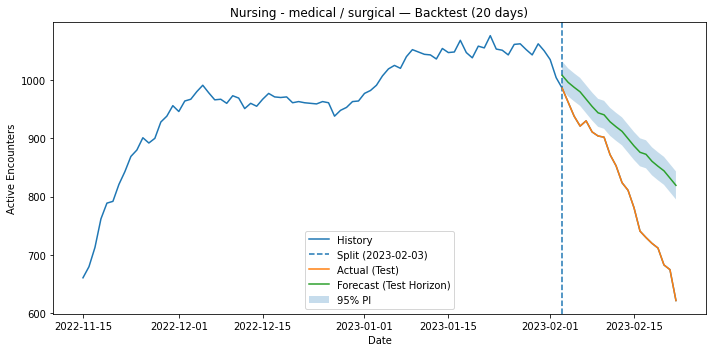

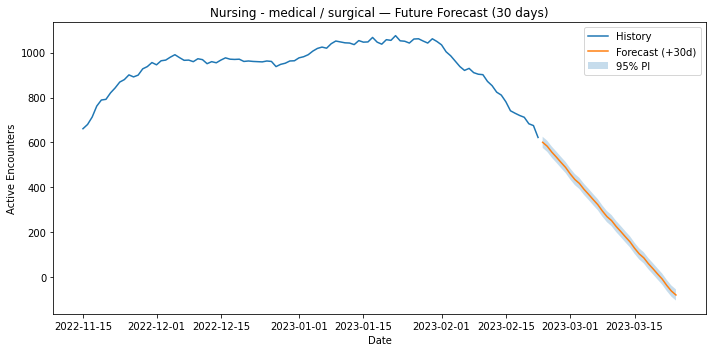



=== Backtest metrics for Emergency medicine (holdout 20 days) ===
MAE:  6.969
RMSE: 8.151
MAPE: 21.49%


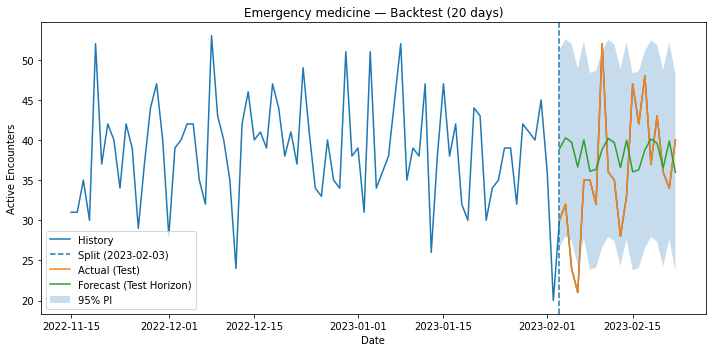

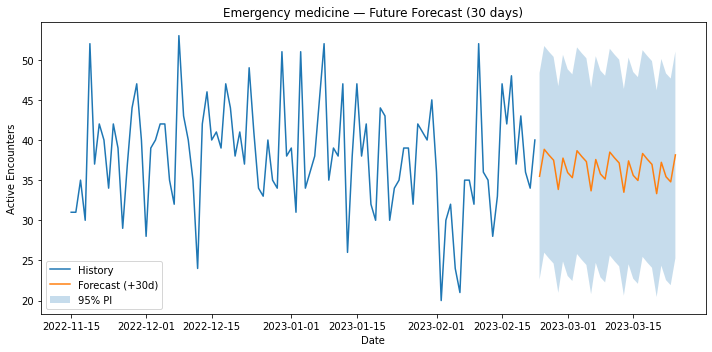

In [6]:
# ========= Run backtest + future forecast for each department =========
rows = []
for dept in departments:
    y = pivot[dept].astype(float)
    if y.nunique() <= 1:
        print(f"[Warn] {dept} has near-constant series; forecasts may be flat.")

    # ---- Backtest on last `test_h` days ----
    bt = backtest_one(y, test_h=test_h, seasonal_periods=seasonal_periods)
    print(f"\n=== Backtest metrics for {dept} (holdout {test_h} days) ===")
    print(f"MAE:  {bt['mae']:.3f}")
    print(f"RMSE: {bt['rmse']:.3f}")
    print(f"MAPE: {bt['mape']:.2f}%")
    rows.append({"department": dept, "MAE": bt["mae"], "RMSE": bt["rmse"], "MAPE_%": bt["mape"]})

    # ---- Plot: history with split, test actual vs forecast (with 95% CI) ----
    split_date = bt["test"].index[0]
    plt.figure(figsize=(10, 5))
    plt.plot(y.index, y.values, label="History")
    plt.axvline(split_date, linestyle="--", label=f"Split ({split_date.date()})")
    plt.plot(bt["test"].index, bt["test"].values, label="Actual (Test)")
    plt.plot(bt["fcst"].index, bt["fcst"]["mean"], label="Forecast (Test Horizon)")
    plt.fill_between(bt["fcst"].index, bt["fcst"]["lower_95"], bt["fcst"]["upper_95"], alpha=0.25, label="95% PI")
    plt.title(f"{dept} — Backtest ({test_h} days)")
    plt.xlabel("Date"); plt.ylabel("Active Encounters")
    plt.legend(); plt.tight_layout(); plt.show()

    # ---- Refit on full history and forecast next `future_h` days ----
    fcst_future, fit_full = robust_ets_forecast(y, h=future_h, seasonal_periods=seasonal_periods)

    # ---- Plot: history + future forecast (with 95% CI) ----
    plt.figure(figsize=(10, 5))
    plt.plot(y.index, y.values, label="History")
    plt.plot(fcst_future.index, fcst_future["mean"], label=f"Forecast (+{future_h}d)")
    plt.fill_between(fcst_future.index, fcst_future["lower_95"], fcst_future["upper_95"], alpha=0.25, label="95% PI")
    plt.title(f"{dept} — Future Forecast ({future_h} days)")
    plt.xlabel("Date"); plt.ylabel("Active Encounters")
    plt.legend(); plt.tight_layout(); plt.show()